# Gross Credit Loss Forecasting Pipeline (Hybrid SARIMAX + Darts Error Correction)

This notebook implements the requested architecture using script modules and config-driven settings.

In [ ]:
%%capture
!pip install --upgrade pyyaml pandas numpy matplotlib seaborn statsmodels scikit-learn u8darts

In [1]:
import datetime
import importlib
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning

from darts import TimeSeries
from darts.models import SKLearnModel

from scripts.config_utils import load_config
from scripts.data_utils import load_metric_dataframe, build_series
import scripts.stationarity_analysis as stationarity_analysis
import scripts.modeling as modeling
importlib.reload(stationarity_analysis)
importlib.reload(modeling)
from scripts.stationarity_analysis import (
    adf_test,
    plot_stationary_diagnostics,
    detect_seasonality_with_darts,
    suggest_pq_bounds_from_acf_pacf,
)
from scripts.modeling import build_expanding_validation_splits
from scripts.hybrid import (
    historical_one_step_predictions,
    compute_base_residuals_with_historical_forecasts,
    error_diagnostics,
)

sns.set_style('whitegrid')

Support for PyTorch based likelihood models not available. To enable them, install "darts[torch]" or "darts[all]" (with pip); or "u8darts-torch" or "u8darts-all" (with conda).
Support for Torch based models not available. To enable them, install "darts[torch]" or "darts[all]" (with pip); or "u8darts-torch" or "u8darts-all" (with conda).
The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


# 1) Load Configuration and Data

In [2]:
config = load_config('config.yaml')
raw_df = load_metric_dataframe(config)

target_metric = config['metric']
target_series = build_series(config, raw_df, target_metric)

combined = pd.DataFrame({'target': target_series}).dropna().sort_index()
combined.index = pd.DatetimeIndex(combined.index)

train_start = pd.Timestamp(config['first_input_date'])
train_end = pd.Timestamp(config['last_input_date'])
test_start = pd.Timestamp(config['test_start_date'])
test_end = pd.Timestamp(config['test_end_date'])
last_test = pd.Timestamp(config['last_test_date'])

train_df = combined[(combined.index >= train_start) & (combined.index <= train_end)].copy()
test_df = combined[(combined.index >= test_start) & (combined.index <= test_end)].copy()

test_freq = str(config.get('frequency', 'ME'))
try:
    test_horizon_index = pd.date_range(start=test_start, end=last_test, freq=test_freq)
except Exception:
    test_horizon_index = pd.date_range(start=test_start, end=last_test, freq='M')

test_horizon_index = pd.DatetimeIndex(test_horizon_index)

if pd.infer_freq(train_df.index) is not None:
    train_df = train_df.asfreq(pd.infer_freq(train_df.index))

benchmark_labels = list(config.get('benchmark_forecast_types', ['Original base case', '2024 0+12']))

print(f"Train rows: {len(train_df)} ({train_df.index.min()} -> {train_df.index.max()})")
print(f"Actual eval rows: {len(test_df)} ({test_df.index.min()} -> {test_df.index.max()})")
print(f"Forecast horizon rows: {len(test_horizon_index)} ({test_horizon_index.min()} -> {test_horizon_index.max()})")
print('Benchmarks from config:', benchmark_labels)
display(train_df.head())

Train rows: 49 (2019-12-31 00:00:00 -> 2023-12-31 00:00:00)
Actual eval rows: 2 (2024-01-31 00:00:00 -> 2024-02-29 00:00:00)
Forecast horizon rows: 12 (2024-01-31 00:00:00 -> 2024-12-31 00:00:00)
Benchmarks from config: ['Original base case', '2024 0+12']


,target
DATE,
2019-12-31,3759133.46
2020-01-31,3437823.91
2020-02-29,3575387.21
2020-03-31,3739548.28
2020-04-30,3745378.96


In [3]:
def smape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    den = np.abs(y_true) + np.abs(y_pred)
    den = np.where(den == 0, 1.0, den)
    return float(np.mean(2 * np.abs(y_true - y_pred) / den) * 100)


def print_metrics(label: str, y_true: np.ndarray, y_pred: np.ndarray) -> None:
    print(f"  {label}")
    print(f"    MAPE  : {mean_absolute_percentage_error(y_true, y_pred) * 100:.2f}%")
    print(f"    SMAPE : {smape(y_true, y_pred):.2f}%")
    print(f"    RMSE  : {np.sqrt(mean_squared_error(y_true, y_pred)):>14,.2f}")


def get_benchmark(test_dates, forecast_label: str):
    mask = (
        (raw_df[config['columns']['portfolio']] == config['portfolio']) &
        (raw_df[config['columns']['sub_portfolio']] == config['sub_portfolio']) &
        (raw_df[config['columns']['metric']] == target_metric) &
        (raw_df[config['columns']['forecast_type']] == forecast_label)
    )
    bdf = raw_df.loc[mask, [config['columns']['date'], config['columns']['value']]].copy()
    bdf.columns = ['DATE', 'METRIC_VALUE']
    bdf['FORECAST_TYPE'] = forecast_label
    bdf['DATE'] = pd.to_datetime(bdf['DATE'])
    return bdf[bdf['DATE'].isin(pd.to_datetime(test_dates))]


def build_pred_df(model_values, dates, test_y=None):
    model_rows = pd.DataFrame({
        'DATE': pd.to_datetime(dates),
        'FORECAST_TYPE': 'Model Forecast',
        'METRIC_VALUE': np.asarray(model_values, dtype=float),
    })

    dfs = [model_rows]
    for bl in benchmark_labels:
        b = get_benchmark(dates, bl)
        if not b.empty:
            dfs.append(b[['DATE', 'FORECAST_TYPE', 'METRIC_VALUE']])

    if test_y is not None:
        actual_rows = pd.DataFrame({
            'DATE': pd.to_datetime(test_y.index),
            'FORECAST_TYPE': 'Actual',
            'METRIC_VALUE': test_y.values.astype(float),
        })
        dfs.append(actual_rows)

    out = pd.concat(dfs, ignore_index=True)
    out['DATE'] = pd.to_datetime(out['DATE'])
    return out


def evaluate_pred_df(pred_df: pd.DataFrame, model_label: str = 'Model Forecast') -> None:
    y_actual = (
        pred_df[pred_df['FORECAST_TYPE'] == 'Actual']
        .sort_values('DATE').set_index('DATE')['METRIC_VALUE']
    )
    labels = [model_label] + benchmark_labels
    print(f"\n{'='*60}")
    print(f"Forecast Metrics — {target_metric}")
    print(f"{'='*60}")
    for lbl in labels:
        y_pred = (
            pred_df[pred_df['FORECAST_TYPE'] == lbl]
            .sort_values('DATE').set_index('DATE')['METRIC_VALUE']
        )
        common = y_actual.index.intersection(y_pred.index)
        if len(common) == 0:
            print(f"\n  {lbl} - no overlapping dates")
            continue
        yt = y_actual.loc[common].values.astype(float)
        yp = y_pred.loc[common].values.astype(float)
        print_metrics(lbl, yt, yp)
    print(f"{'='*60}")


def plot_results(pred_df: pd.DataFrame, title: str) -> None:
    palette = {'Actual': '#2E86DE', 'Model Forecast': '#E67E22', 'Original base case': '#27AE60', '2024 0+12': '#8E44AD'}
    all_dates = sorted(pred_df['DATE'].dt.strftime('%Y-%m-%d').unique())

    fig, ax = plt.subplots(figsize=(18, 6))
    ax.set_title(title, fontsize=14, fontweight='bold')

    for lbl in ['Actual', 'Model Forecast'] + benchmark_labels:
        sub = pred_df[pred_df['FORECAST_TYPE'] == lbl].copy()
        if sub.empty:
            continue
        sub['DATE_STR'] = sub['DATE'].dt.strftime('%Y-%m-%d')
        sub = sub.sort_values('DATE_STR')
        x_idx = [all_dates.index(d) for d in sub['DATE_STR']]
        ax.plot(x_idx, sub['METRIC_VALUE'].values, marker='o', linewidth=2, label=lbl, color=palette.get(lbl, None))

    ax.set_xticks(range(len(all_dates)))
    ax.set_xticklabels(all_dates, rotation=90)
    ax.set_xlabel('DATE')
    ax.set_ylabel('METRIC_VALUE')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.2f}'))
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=3)
    plt.tight_layout()
    plt.show()

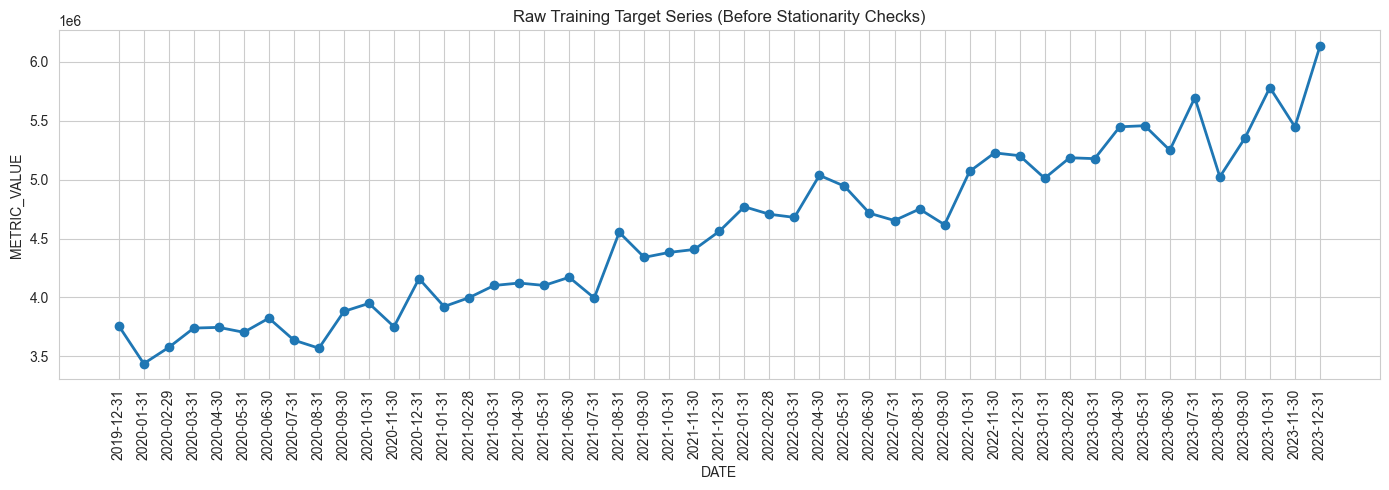

In [4]:
# Quick view of target before stationarity analysis
plt.figure(figsize=(14, 5))
plt.plot(train_df.index.astype(str), train_df['target'].values, marker='o', linewidth=2)
plt.title('Raw Training Target Series (Before Stationarity Checks)')
plt.xlabel('DATE')
plt.ylabel('METRIC_VALUE')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 2) Phase 1 - Manual Stationarity and Seasonal Diagnostics

Manual approach requested:
- First check ADF on raw training data.
- Keep `.diff()` and `.diff().diff(12)` as commented options.
- Use final chosen series for ACF/PACF and decomposition.
- Run Darts seasonality check, then re-check after seasonal period update.

In [5]:
alpha = float(config['stationarity']['adf_alpha'])

raw_series = train_df['target'].astype(float).copy()
adf_raw = adf_test(raw_series, alpha=alpha)
print('ADF on raw train target:')
print(adf_raw)

final_series = raw_series.copy()
print('\nUsing raw series for diagnostics. If non-stationary, uncomment differencing below.')

# If raw series is non-stationary, uncomment this block:
final_series = raw_series.diff().dropna()
print('\nADF after diff(1):')
print(adf_test(final_series, alpha=alpha))

# If still non-stationary and seasonal pattern is strong, uncomment this block:
# final_series = raw_series.diff().diff(12).dropna()
# print('\nADF after diff(1)+diff(12):')
# print(adf_test(final_series, alpha=alpha))

ADF on raw train target:
{'adf_stat': 0.5774706103902569, 'p_value': 0.9870469517060944, 'n_lags': 5, 'n_obs': 43, 'critical_values': {'1%': np.float64(-3.5925042342183704), '5%': np.float64(-2.931549768951162), '10%': np.float64(-2.60406594375338)}, 'is_stationary': False}

Using raw series for diagnostics. If non-stationary, uncomment differencing below.

ADF after diff(1):
{'adf_stat': -4.93397624036615, 'p_value': 2.9935156679468848e-05, 'n_lags': 4, 'n_obs': 43, 'critical_values': {'1%': np.float64(-3.5925042342183704), '5%': np.float64(-2.931549768951162), '10%': np.float64(-2.60406594375338)}, 'is_stationary': True}


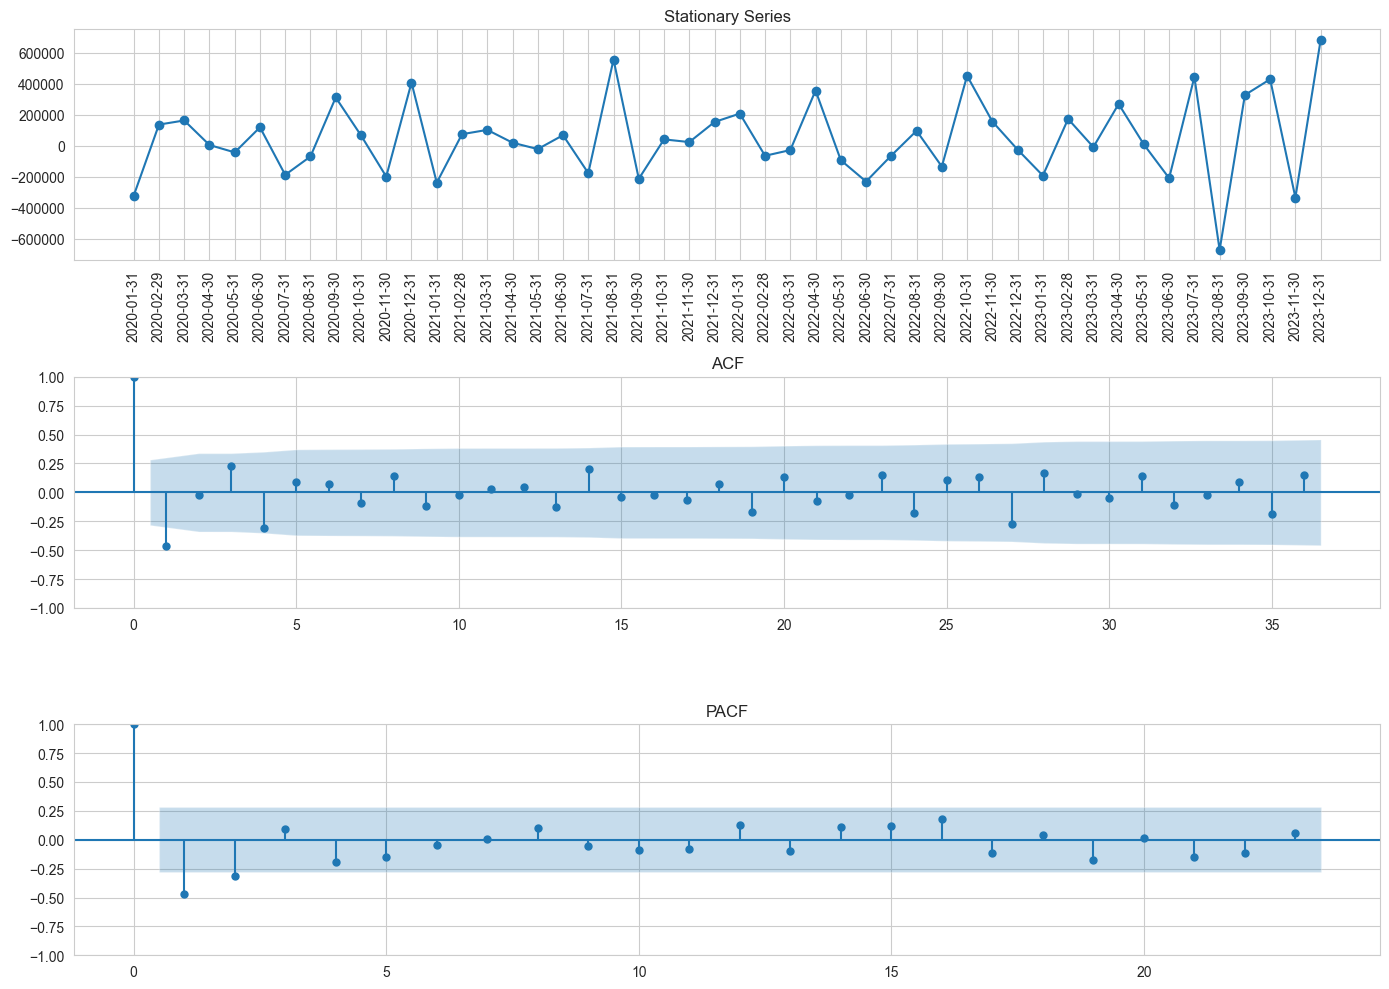

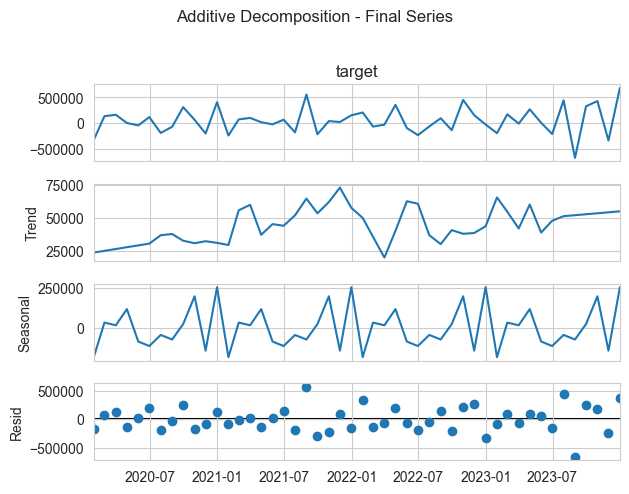

Multiplicative decomposition skipped: final series contains non-positive values.
Darts seasonality check #1 -> has_seasonality=True, period=3
Seasonal period selected for modeling: 3
Darts seasonality check #2 (after seasonal period update) -> has_seasonality=True, period=3
Suggested p/q upper bounds from diagnostics: {'p_max': 2, 'q_max': 4}


In [6]:
plot_stationary_diagnostics(
    final_series,
    max_acf_lag=int(config['stationarity']['max_acf_lag']),
    max_pacf_lag=int(config['stationarity']['max_pacf_lag']),
)

# Seasonal decomposition (12 months) on final selected series
decomp_add = seasonal_decompose(
    final_series.astype(float),
    model='additive',
    period=12,
    extrapolate_trend='freq',
)
decomp_add.plot();
plt.suptitle('Additive Decomposition - Final Series', y=1.02)
plt.tight_layout()
plt.show()

if (final_series > 0).all():
    decomp_mul = seasonal_decompose(
        final_series.astype(float),
        model='multiplicative',
        period=12,
        extrapolate_trend='freq',
    )
    decomp_mul.plot();
    plt.suptitle('Multiplicative Decomposition - Final Series', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('Multiplicative decomposition skipped: final series contains non-positive values.')

has_seasonality_1, detected_period_1 = detect_seasonality_with_darts(
    final_series,
    max_lag=int(config['stationarity']['seasonal_check_max_lag']),
)
print(f"Darts seasonality check #1 -> has_seasonality={has_seasonality_1}, period={detected_period_1}")

seasonal_period = int(detected_period_1) if detected_period_1 else int(config['seasonal_period'])
print(f"Seasonal period selected for modeling: {seasonal_period}")

has_seasonality_2, detected_period_2 = detect_seasonality_with_darts(
    final_series,
    max_lag=max(12, seasonal_period * 3),
)
print(f"Darts seasonality check #2 (after seasonal period update) -> has_seasonality={has_seasonality_2}, period={detected_period_2}")

bounds = suggest_pq_bounds_from_acf_pacf(final_series, max_lag=24)
print(f"Suggested p/q upper bounds from diagnostics: {bounds}")

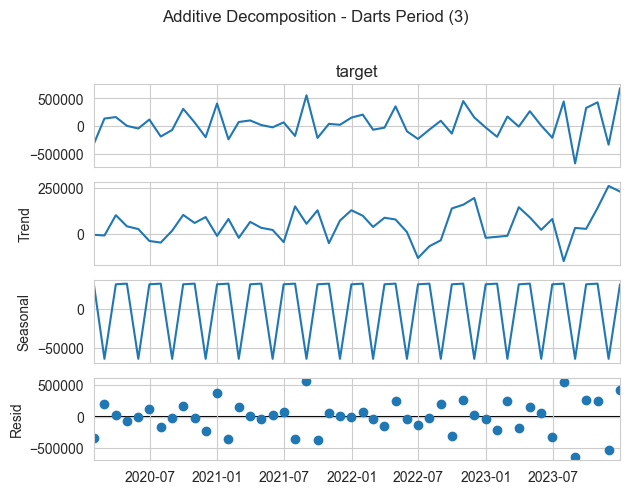

Multiplicative decomposition skipped for Darts period: non-positive values in final series.


In [7]:
# Re-run decomposition using seasonal period selected from Darts
decomp_add_darts_period = seasonal_decompose(
    final_series.astype(float),
    model='additive',
    period=seasonal_period,
    extrapolate_trend='freq',
)
decomp_add_darts_period.plot();
plt.suptitle(f'Additive Decomposition - Darts Period ({seasonal_period})', y=1.02)
plt.tight_layout()
plt.show()

if (final_series > 0).all():
    decomp_mul_darts_period = seasonal_decompose(
        final_series.astype(float),
        model='multiplicative',
        period=seasonal_period,
        extrapolate_trend='freq',
    )
    decomp_mul_darts_period.plot();
    plt.suptitle(f'Multiplicative Decomposition - Darts Period ({seasonal_period})', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('Multiplicative decomposition skipped for Darts period: non-positive values in final series.')

# 3) Base-Model Hyperparameter Tuning (MAPE Only)

Tuning objective is only AVG_MAPE across validation splits.
AIC/BIC are printed for diagnostics, but not used for ranking.

In [8]:
seasonal_period = int(config.get('seasonal_period', 12))

# User-defined initial SARIMA parameters
initial_order = (1, 1, 1)
initial_seasonal = (1, 1, 0, seasonal_period)

# User-defined SARIMA search grid
grid_cfg_notebook = {
    'p': [0, 1, 2],
    'd': [0, 1],
    'q': [0, 1, 2],
    'P': [0, 1],
    'D': [0],
    'Q': [0, 1],
    'S': seasonal_period,
}

# Residual ML hyperparameter grid (includes lag tuning)
ml_grid_cfg = {
    'lags': [3, 6, 9],
    'n_estimators': [150, 300],
    'max_depth': [3, 6],
    'min_samples_leaf': [1, 2],
}
ml_grid = [
    {
        'lags': int(lg),
        'n_estimators': int(ne),
        'max_depth': int(md),
        'min_samples_leaf': int(msl),
        'random_state': 42,
    }
    for lg, ne, md, msl in itertools.product(
        ml_grid_cfg['lags'],
        ml_grid_cfg['n_estimators'],
        ml_grid_cfg['max_depth'],
        ml_grid_cfg['min_samples_leaf'],
    )
]


def fit_sarima_notebook(y: pd.Series, order: tuple, seasonal_order: tuple, maxiter: int = 40):
    model = SARIMAX(
        endog=y.astype(float),
        exog=None,
        order=order,
        seasonal_order=seasonal_order,
        trend='n',
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', ValueWarning)
        warnings.simplefilter('ignore', FutureWarning)
        warnings.simplefilter('ignore', ConvergenceWarning)
        warnings.simplefilter('ignore', UserWarning)
        warnings.simplefilter('ignore', RuntimeWarning)
        fitted = model.fit(disp=False, maxiter=maxiter, method='lbfgs', cov_type='none')
    return fitted


def forecast_sarima_notebook(fitted, future_index: pd.DatetimeIndex) -> pd.Series:
    fc = fitted.get_forecast(steps=len(future_index)).predicted_mean
    return pd.Series(np.asarray(fc, dtype=float), index=future_index)


def is_viable_sarima_setup(n_obs: int, order: tuple, seasonal_order: tuple) -> bool:
    p, d, q = order
    P, D, Q, S = seasonal_order
    dynamic_terms = p + q + P + Q

    if n_obs < 12:
        return False
    if S < 0:
        return False
    if d + D > 2:
        return False
    if n_obs < 48 and dynamic_terms > 3:
        return False
    if n_obs < 60 and dynamic_terms > 4:
        return False
    if S > 1 and (P + Q) > 0 and n_obs <= S * 2:
        return False
    if S > 1 and D > 0 and n_obs <= S * 3:
        return False

    required = 8 + d + (D * max(S, 1)) + p + q + ((P + Q) * max(S, 1))
    return n_obs > required


sarima_param_grid = list(itertools.product(
    grid_cfg_notebook['p'],
    grid_cfg_notebook['d'],
    grid_cfg_notebook['q'],
    grid_cfg_notebook['P'],
    grid_cfg_notebook['D'],
    grid_cfg_notebook['Q'],
))

print('Initial SARIMA order:', initial_order)
print('Initial SARIMA seasonal order:', initial_seasonal)
print('SARIMA grid used in notebook:')
print(grid_cfg_notebook)
print(f'Total SARIMA combinations: {len(sarima_param_grid)}')
print('\nResidual ML grid (Darts SKLearnModel + RandomForestRegressor):')
print(f"Total ML combinations: {len(ml_grid)}")
display(pd.DataFrame(ml_grid).head(10))

Initial SARIMA order: (1, 1, 1)
Initial SARIMA seasonal order: (1, 1, 0, 12)
SARIMA grid used in notebook:
{'p': [0, 1, 2], 'd': [0, 1], 'q': [0, 1, 2], 'P': [0, 1], 'D': [0], 'Q': [0, 1], 'S': 12}
Total SARIMA combinations: 72

Residual ML grid (Darts SKLearnModel + RandomForestRegressor):
Total ML combinations: 24


,lags,n_estimators,max_depth,min_samples_leaf,random_state
0,3,150,3,1,42
1,3,150,3,2,42
2,3,150,6,1,42
3,3,150,6,2,42
4,3,300,3,1,42
5,3,300,3,2,42
6,3,300,6,1,42
7,3,300,6,2,42
8,6,150,3,1,42
9,6,150,3,2,42


In [9]:
val_cfg = config['validation']
splits = build_expanding_validation_splits(
    train_start=val_cfg['train_start'],
    valid_start=val_cfg['valid_start'],
    valid_end=val_cfg['valid_end'],
    step_months=int(val_cfg.get('step_months', 3)),
)

print('Auto-generated expanding validation splits:')
display(pd.DataFrame(splits))

rows = []
for p, d, q, P, D, Q in sarima_param_grid:
    order = (int(p), int(d), int(q))
    seasonal_order = (int(P), int(D), int(Q), int(grid_cfg_notebook['S']))

    if not is_viable_sarima_setup(len(train_df), order, seasonal_order):
        continue

    split_mapes = []
    aic_ref = np.nan
    bic_ref = np.nan

    for sp in splits:
        tr_start = pd.Timestamp(sp['train_start'])
        tr_end = pd.Timestamp(sp['train_end'])
        va_start = pd.Timestamp(sp['valid_start'])
        va_end = pd.Timestamp(sp['valid_end'])

        tr_y = train_df['target'][(train_df.index >= tr_start) & (train_df.index <= tr_end)]
        va_y = train_df['target'][(train_df.index >= va_start) & (train_df.index <= va_end)]

        if len(tr_y) < 18 or len(va_y) == 0:
            continue
        if not is_viable_sarima_setup(len(tr_y), order, seasonal_order):
            continue

        try:
            fit = fit_sarima_notebook(tr_y, order, seasonal_order, maxiter=40)
            pred = forecast_sarima_notebook(fit, va_y.index)
            mape = mean_absolute_percentage_error(va_y.values.astype(float), pred.values.astype(float)) * 100
            split_mapes.append(float(mape))

            if np.isnan(aic_ref):
                aic_ref = float(fit.aic)
                bic_ref = float(fit.bic)
        except Exception:
            continue

    if not split_mapes:
        continue

    rows.append({
        'p': order[0],
        'd': order[1],
        'q': order[2],
        'P': seasonal_order[0],
        'D': seasonal_order[1],
        'Q': seasonal_order[2],
        'S': seasonal_order[3],
        'AVG_MAPE': float(np.mean(split_mapes)),
        'AIC': aic_ref,
        'BIC': bic_ref,
        'n_splits': int(len(split_mapes)),
    })

leaderboard = pd.DataFrame(rows).sort_values(['AVG_MAPE', 'AIC']).reset_index(drop=True)

if leaderboard.empty:
    raise RuntimeError('No valid models fitted in base-model SARIMA grid search.')

top10_base = leaderboard[['p','d','q','P','D','Q','S','AVG_MAPE','AIC','BIC','n_splits']].head(10)
print('Top 10 Base-Model SARIMA Params (sorted by AVG_MAPE only):')
display(top10_base)

best_base = leaderboard.iloc[0]
best_order = (int(best_base.p), int(best_base.d), int(best_base.q))
best_seasonal = (int(best_base.P), int(best_base.D), int(best_base.Q), int(best_base.S))

print('Best base SARIMA params (MAPE-only tuning):')
print('order =', best_order)
print('seasonal_order =', best_seasonal)
print(f"AVG_MAPE={best_base.AVG_MAPE:.4f} | AIC={best_base.AIC:.2f} | BIC={best_base.BIC:.2f}")

Auto-generated expanding validation splits:


,name,train_start,train_end,valid_start,valid_end
0,split_1,2019-12-31,2021-12-31,2022-01-31,2023-12-31
1,split_2,2019-12-31,2022-03-31,2022-04-30,2023-12-31
2,split_3,2019-12-31,2022-06-30,2022-07-31,2023-12-31
3,split_4,2019-12-31,2022-09-30,2022-10-31,2023-12-31
4,split_5,2019-12-31,2022-12-31,2023-01-31,2023-12-31
5,split_6,2019-12-31,2023-03-31,2023-04-30,2023-12-31
6,split_7,2019-12-31,2023-06-30,2023-07-31,2023-12-31
7,split_8,2019-12-31,2023-09-30,2023-10-31,2023-12-31


Top 10 Base-Model SARIMA Params (sorted by AVG_MAPE only):


,p,d,q,P,D,Q,S,AVG_MAPE,AIC,BIC,n_splits
0,2,0,1,0,0,0,12,4.347173,609.735285,614.277261,8
1,1,0,1,0,0,0,12,4.441149,616.427295,619.833778,8
2,0,0,1,1,0,1,12,4.546797,655.516305,659.499234,5
3,0,0,0,1,0,1,12,4.548086,595.180929,598.314496,5
4,0,0,0,1,0,0,12,4.624599,354.845964,355.975863,8
5,1,0,2,0,0,0,12,4.630805,589.217327,593.581497,8
6,1,0,1,1,0,0,12,4.642013,333.724324,335.663951,8
7,2,0,0,1,0,0,12,4.924438,301.827149,303.418730,8
8,2,0,0,0,0,0,12,5.012326,622.481339,625.887821,8
9,2,0,0,0,0,1,12,5.147035,327.631055,329.570682,8


Best base SARIMA params (MAPE-only tuning):
order = (2, 0, 1)
seasonal_order = (0, 0, 0, 12)
AVG_MAPE=4.3472 | AIC=609.74 | BIC=614.28


In [11]:
# Residual-model tuning using Darts SKLearnModel + RandomForestRegressor
# Base SARIMA parameters are fixed from previous cell (best_order / best_seasonal)

base_fit_for_residual = fit_sarima_notebook(train_df['target'], best_order, best_seasonal, maxiter=50)
base_train_pred_for_error = base_fit_for_residual.get_prediction(
    start=train_df.index[0],
    end=train_df.index[-1],
).predicted_mean
base_train_pred_for_error = pd.Series(base_train_pred_for_error.values, index=train_df.index)

error_series_full = (train_df['target'] - base_train_pred_for_error).dropna()
print(f'Error series rows for tuning: {len(error_series_full)}')

ml_rows = []
for ml_cfg in ml_grid:
    lag_k = int(ml_cfg['lags'])
    split_mapes = []

    for sp in splits:
        tr_start = pd.Timestamp(sp['train_start'])
        tr_end = pd.Timestamp(sp['train_end'])
        va_start = pd.Timestamp(sp['valid_start'])
        va_end = pd.Timestamp(sp['valid_end'])

        tr_y = train_df['target'][(train_df.index >= tr_start) & (train_df.index <= tr_end)]
        va_y = train_df['target'][(train_df.index >= va_start) & (train_df.index <= va_end)]
        if len(tr_y) < 24 or len(va_y) == 0:
            continue

        try:
            # Base SARIMA for this split (already tuned hyperparameters)
            split_base_fit = fit_sarima_notebook(tr_y, best_order, best_seasonal, maxiter=40)
            base_tr_pred = split_base_fit.get_prediction(start=tr_y.index[0], end=tr_y.index[-1]).predicted_mean
            base_tr_pred = pd.Series(base_tr_pred.values, index=tr_y.index)
            base_va_pred = forecast_sarima_notebook(split_base_fit, va_y.index)

            split_residual_train = (tr_y - base_tr_pred).dropna()
            if len(split_residual_train) <= lag_k + 2:
                continue

            # Darts residual model definition is explicit in notebook as requested.
            residual_ts = TimeSeries.from_series(split_residual_train.astype(float))
            rf_model = RandomForestRegressor(
                n_estimators=int(ml_cfg['n_estimators']),
                max_depth=int(ml_cfg['max_depth']),
                min_samples_leaf=int(ml_cfg['min_samples_leaf']),
                random_state=int(ml_cfg['random_state']),
            )
            residual_model = SKLearnModel(model=rf_model, lags=lag_k)
            residual_model.fit(residual_ts)

            residual_fc_ts = residual_model.predict(n=len(va_y))
            residual_fc = np.asarray(residual_fc_ts.values()).reshape(-1)

            hybrid_va_pred = base_va_pred.values.astype(float) + residual_fc
            mape = mean_absolute_percentage_error(va_y.values.astype(float), hybrid_va_pred) * 100
            split_mapes.append(float(mape))
        except Exception:
            continue

    if not split_mapes:
        continue

    ml_rows.append({
        'MODEL': 'Darts SKLearnModel(RandomForest)',
        'lags': lag_k,
        'n_estimators': int(ml_cfg['n_estimators']),
        'max_depth': int(ml_cfg['max_depth']),
        'min_samples_leaf': int(ml_cfg['min_samples_leaf']),
        'AVG_MAPE': float(np.mean(split_mapes)),
        'n_splits': int(len(split_mapes)),
    })

err_leaderboard = pd.DataFrame(ml_rows).sort_values(['AVG_MAPE']).reset_index(drop=True)

if err_leaderboard.empty:
    raise RuntimeError('No valid residual ML models fitted in error-model grid search.')

top10_err = err_leaderboard.head(10)
print('Top Residual-Model Params (sorted by AVG_MAPE only):')
display(top10_err)

best_err = err_leaderboard.iloc[0]
best_ml_params = {
    'lags': int(best_err.lags),
    'n_estimators': int(best_err.n_estimators),
    'max_depth': int(best_err.max_depth),
    'min_samples_leaf': int(best_err.min_samples_leaf),
    'random_state': 42,
}

print('Best residual ML model params (MAPE-only tuning):')
print('model = Darts SKLearnModel(RandomForestRegressor)')
print(best_ml_params)
print(f"AVG_MAPE={best_err.AVG_MAPE:.4f}")

Error series rows for tuning: 49
Top Residual-Model Params (sorted by AVG_MAPE only):


,MODEL,lags,n_estimators,max_depth,min_samples_leaf,AVG_MAPE,n_splits
0,Darts SKLearnModel(RandomForest),6,150,6,2,4.193904,8
1,Darts SKLearnModel(RandomForest),6,300,3,2,4.201933,8
2,Darts SKLearnModel(RandomForest),9,300,6,2,4.203640,8
3,Darts SKLearnModel(RandomForest),9,300,3,2,4.211205,8
4,Darts SKLearnModel(RandomForest),9,150,6,2,4.217027,8
5,Darts SKLearnModel(RandomForest),9,150,3,2,4.222838,8
6,Darts SKLearnModel(RandomForest),6,300,6,2,4.230646,8
7,Darts SKLearnModel(RandomForest),6,150,3,2,4.245700,8
8,Darts SKLearnModel(RandomForest),9,150,6,1,4.250408,8
9,Darts SKLearnModel(RandomForest),9,300,6,1,4.253184,8


Best residual ML model params (MAPE-only tuning):
model = Darts SKLearnModel(RandomForestRegressor)
{'lags': 6, 'n_estimators': 150, 'max_depth': 6, 'min_samples_leaf': 2, 'random_state': 42}
AVG_MAPE=4.1939


# 4) Hybrid Forecasting Logic and Test-Horizon Prediction

This section implements a two-stage hybrid approach:

1. **Stage A - Statistical signal (SARIMA)**  
   Use the best SARIMA hyperparameters selected from validation splits to model the core time-series structure (level, trend, and seasonality).

2. **Stage B - Residual correction (Darts SKLearnModel + RandomForestRegressor)**  
   Compute residuals from SARIMA in-sample predictions, then fit a non-linear ML model on residual history to learn remaining patterns SARIMA did not capture.

3. **Hybrid forecast composition**  
   Final forecast = `SARIMA forecast + Residual ML forecast`.

4. **Test-horizon handling requested in this notebook**
   - Forecast horizon runs from `test_start_date` to `last_test_date`.
   - Actuals may only be available from `test_start_date` to `test_end_date`.
   - Plots show the full horizon for Model Forecast and benchmark curves.
   - Metrics are computed only on overlapping dates where actual values are available.

,DATE,FORECAST_TYPE,METRIC_VALUE
14,2024-01-31,2024 0+12,6.045661e+06
16,2024-01-31,Actual,5.813135e+06
0,2024-01-31,Model Forecast,5.842384e+06
12,2024-01-31,Original base case,6.278186e+06
15,2024-02-29,2024 0+12,6.175912e+06
17,2024-02-29,Actual,5.938377e+06
1,2024-02-29,Model Forecast,5.857267e+06
13,2024-02-29,Original base case,6.413447e+06
2,2024-03-31,Model Forecast,6.015079e+06
3,2024-04-30,Model Forecast,5.964913e+06



Forecast Metrics — Gross Credit Losses
  Model Forecast
    MAPE  : 0.93%
    SMAPE : 0.94%
    RMSE  :      60,968.54
  Original base case
    MAPE  : 8.00%
    SMAPE : 7.69%
    RMSE  :     470,087.19
  2024 0+12
    MAPE  : 4.00%
    SMAPE : 3.92%
    RMSE  :     235,043.60


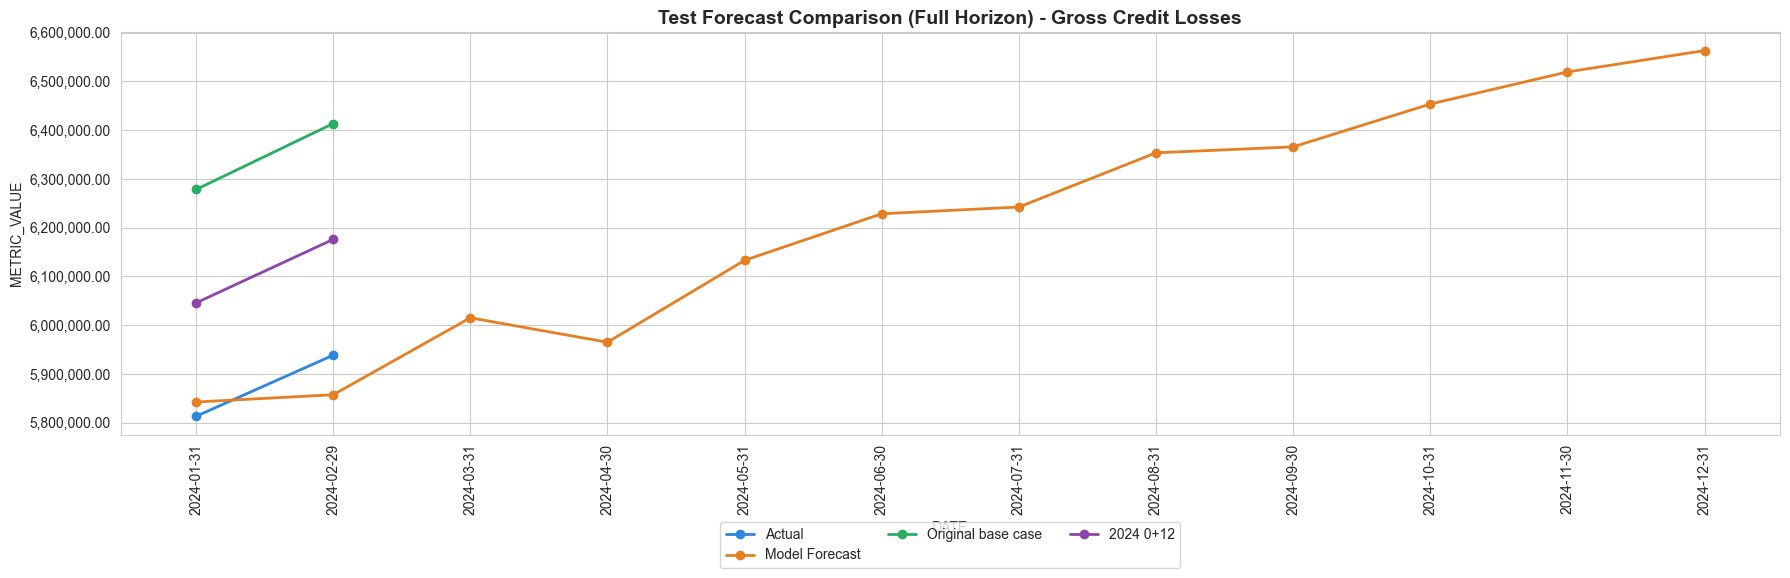

In [12]:
# Train best SARIMA model (explicit definition in notebook)
base_fit_best = fit_sarima_notebook(
    y=train_df['target'],
    order=best_order,
    seasonal_order=best_seasonal,
    maxiter=60,
)

# In-sample SARIMA prediction and residual series for ML training
base_train_pred = base_fit_best.get_prediction(
    start=train_df.index[0],
    end=train_df.index[-1],
).predicted_mean
base_train_pred = pd.Series(base_train_pred.values, index=train_df.index, name='base_train_pred')

error_train_series = (train_df['target'] - base_train_pred).dropna()

# Darts residual model definition and fitting in notebook
rf_model_best = RandomForestRegressor(
    n_estimators=int(best_ml_params['n_estimators']),
    max_depth=int(best_ml_params['max_depth']),
    min_samples_leaf=int(best_ml_params['min_samples_leaf']),
    random_state=int(best_ml_params['random_state']),
)
error_model_best = SKLearnModel(model=rf_model_best, lags=int(best_ml_params['lags']))
error_model_best.fit(TimeSeries.from_series(error_train_series.astype(float)))

# Forecast base and residual on full test horizon: test_start_date -> last_test_date
base_test_fc = forecast_sarima_notebook(base_fit_best, test_horizon_index)
error_test_fc_ts = error_model_best.predict(n=len(test_horizon_index))
error_test_fc = pd.Series(
    np.asarray(error_test_fc_ts.values()).reshape(-1),
    index=test_horizon_index,
    name='error_test_fc',
)

model_test_fc = pd.Series(
    base_test_fc.values.astype(float) + error_test_fc.values.astype(float),
    index=test_horizon_index,
    name='Model Forecast',
)

# Build output using full horizon forecasts/benchmarks + available actual window only
pred_df_test = build_pred_df(model_test_fc.values, test_horizon_index, test_y=test_df['target'])
display(pred_df_test.sort_values(['DATE', 'FORECAST_TYPE']).head(40))

evaluate_pred_df(pred_df_test, model_label='Model Forecast')
plot_results(pred_df_test, f'Test Forecast Comparison (Full Horizon) - {target_metric}')


Training Metrics - Hybrid (SARIMA + Darts Residual ML)
  Model Forecast (Train)
    MAPE  : 3.25%
    SMAPE : 3.25%
    RMSE  :     193,302.84


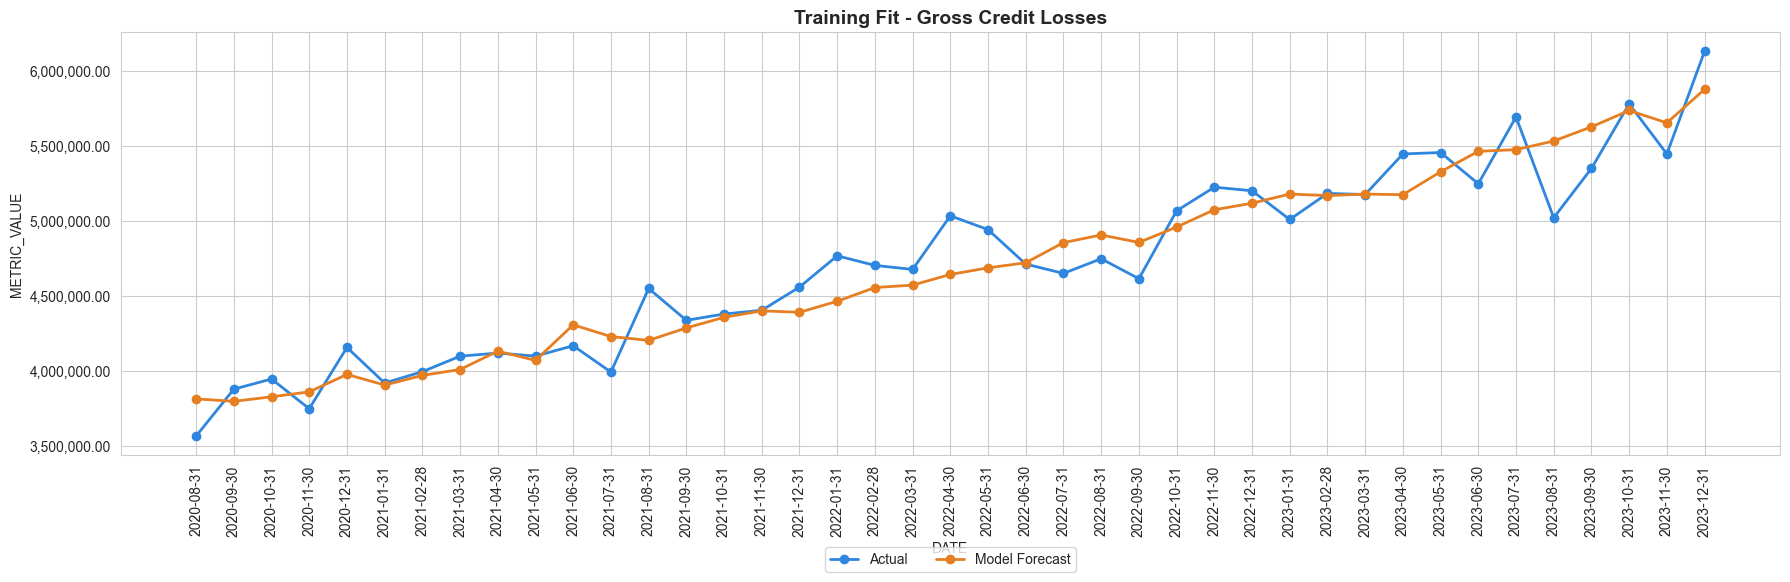

In [13]:
# Training-period diagnostics: how well the hybrid model learned

# One-step recursive residual prediction for training diagnostics
lag_k = int(best_ml_params['lags'])
error_train_pred_vals = []
error_train_pred_idx = []

for i in range(lag_k, len(error_train_series)):
    resid_hist = error_train_series.iloc[:i]
    if len(resid_hist) <= lag_k + 1:
        continue

    rf_tmp = RandomForestRegressor(
        n_estimators=int(best_ml_params['n_estimators']),
        max_depth=int(best_ml_params['max_depth']),
        min_samples_leaf=int(best_ml_params['min_samples_leaf']),
        random_state=int(best_ml_params['random_state']),
    )
    err_tmp = SKLearnModel(model=rf_tmp, lags=lag_k)
    err_tmp.fit(TimeSeries.from_series(resid_hist.astype(float)))
    next_fc = err_tmp.predict(n=1)

    error_train_pred_vals.append(float(np.asarray(next_fc.values()).reshape(-1)[0]))
    error_train_pred_idx.append(error_train_series.index[i])

error_train_pred = pd.Series(error_train_pred_vals, index=error_train_pred_idx, name='error_train_pred')

common_train_idx = train_df.index.intersection(error_train_pred.index)
hybrid_train_pred = pd.Series(
    base_train_pred.loc[common_train_idx].values.astype(float) + error_train_pred.loc[common_train_idx].values.astype(float),
    index=common_train_idx,
    name='Hybrid Train Prediction',
)
train_actual_common = train_df.loc[common_train_idx, 'target'].astype(float)

print('\n' + '='*60)
print('Training Metrics - Hybrid (SARIMA + Darts Residual ML)')
print('='*60)
print_metrics('Model Forecast (Train)', train_actual_common.values, hybrid_train_pred.values)
print('='*60)

train_plot_df = pd.DataFrame({
    'DATE': list(common_train_idx) + list(common_train_idx),
    'FORECAST_TYPE': ['Actual'] * len(common_train_idx) + ['Model Forecast'] * len(common_train_idx),
    'METRIC_VALUE': np.concatenate([train_actual_common.values, hybrid_train_pred.values]),
})
plot_results(train_plot_df, f'Training Fit - {target_metric}')

In [14]:
# Keep historical one-step prediction objects for downstream error time-series analysis
hist_pred = historical_one_step_predictions(
    y_train=train_df['target'],
    exog_train=None,
    order=best_order,
    seasonal_order=best_seasonal,
    start_ratio=0.4,
    min_train_points=24,
)
residual_series = compute_base_residuals_with_historical_forecasts(
    y_train=train_df['target'],
    exog_train=None,
    order=best_order,
    seasonal_order=best_seasonal,
    start_ratio=0.4,
    min_train_points=24,
)

print('Prepared historical predictions and residual series for error diagnostics.')
print(f'hist_pred rows: {len(hist_pred)}, residual rows: {len(residual_series)}')

Prepared historical predictions and residual series for error diagnostics.
hist_pred rows: 25, residual rows: 25


In [14]:
print('Section 5: Error Time Series Analysis')

Section 5: Error Time Series Analysis


Historical one-step base-model error diagnostics:
MAPE: 5.713080
MAE: 302433.399720
RMSE: 361060.595681
BIAS: 290452.356964
ERR_STD: 214481.192853
ERR_LAG1_AUTOCORR: 0.037067

ADF on raw error series:
{'adf_stat': -1.2984491914504719, 'p_value': 0.6298815114752464, 'n_lags': 4, 'n_obs': 20, 'critical_values': {'1%': np.float64(-3.8092091249999998), '5%': np.float64(-3.0216450000000004), '10%': np.float64(-2.6507125)}, 'is_stationary': False}

Using raw error series for diagnostics. Uncomment differencing if needed.


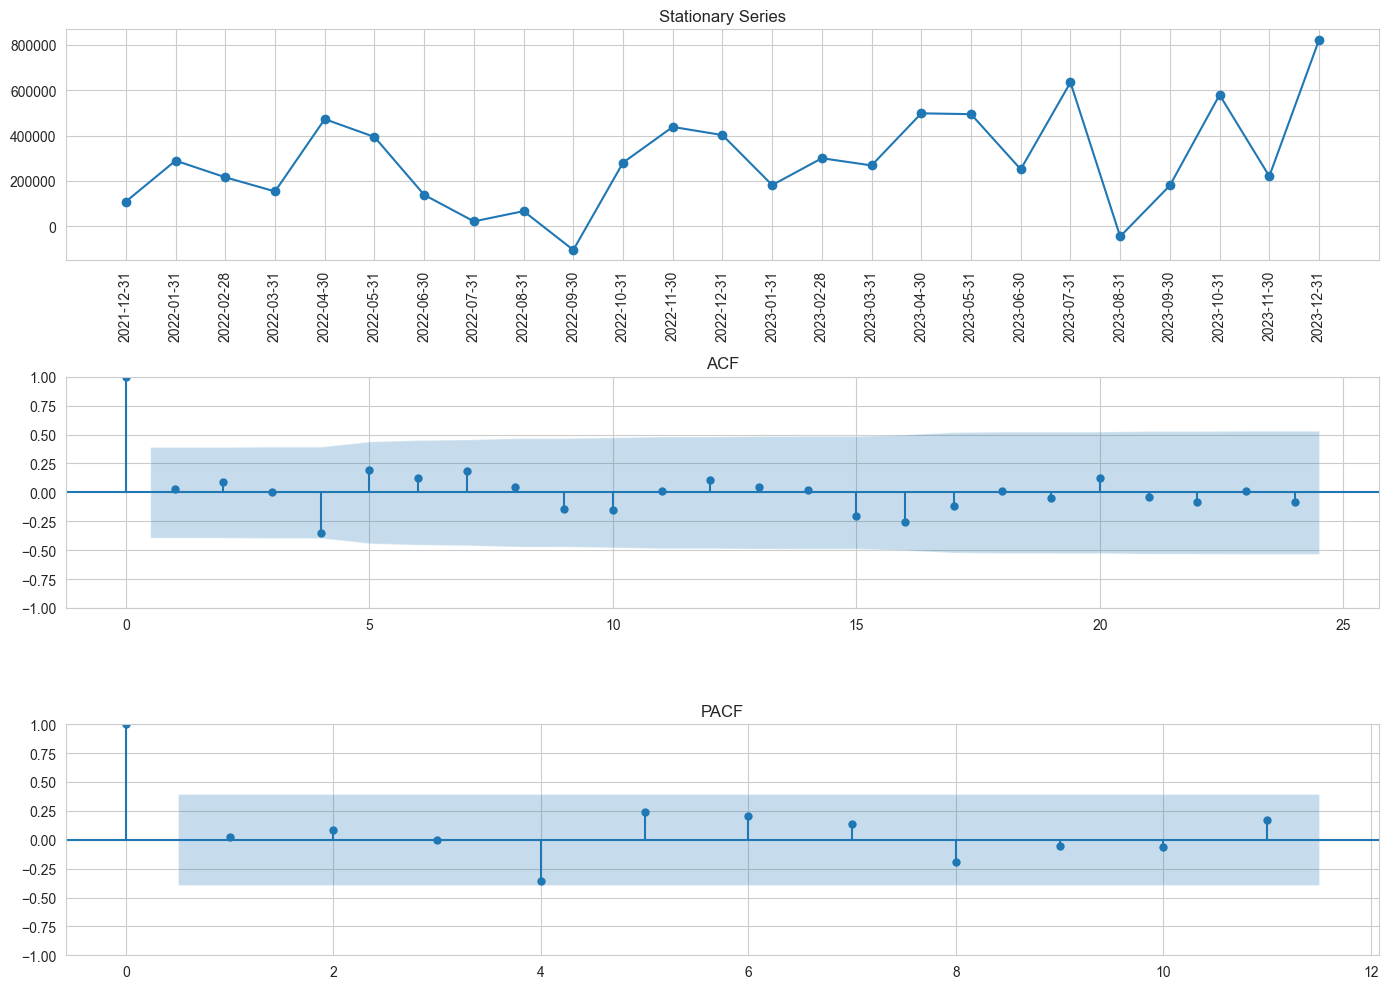

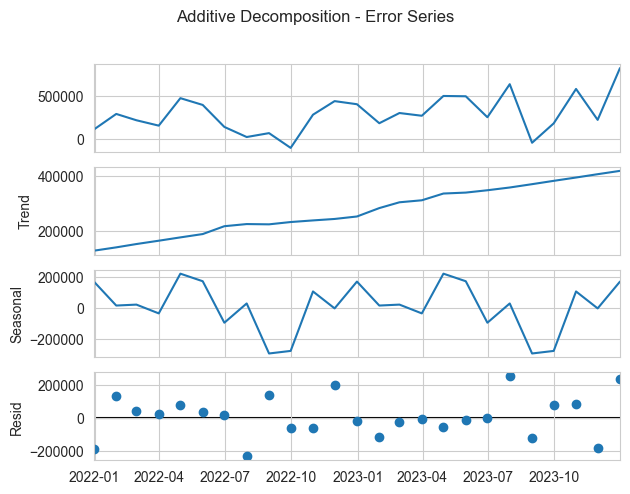

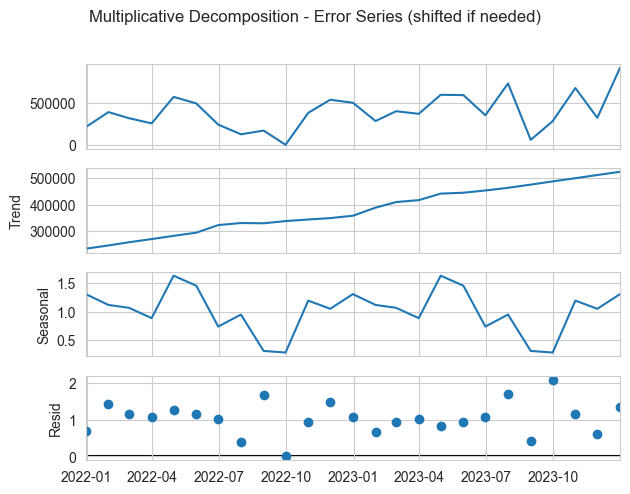

Residual std - additive: 125157.149927
Residual std - multiplicative: 0.450211
Recommended decomposition for error behavior: multiplicative


In [15]:
hist_actual = train_df['target'].loc[hist_pred.index]
error_series = hist_actual - hist_pred

diag = error_diagnostics(hist_actual, hist_pred)
print('Historical one-step base-model error diagnostics:')
for k, v in diag.items():
    print(f"{k}: {v:.6f}")

print('\nADF on raw error series:')
adf_err_raw = adf_test(error_series, alpha=alpha)
print(adf_err_raw)

final_error_series = error_series.copy()
print('\nUsing raw error series for diagnostics. Uncomment differencing if needed.')

# If error series is non-stationary, uncomment this block:
# final_error_series = error_series.diff().dropna()
# print('\nADF after error diff(1):')
# print(adf_test(final_error_series, alpha=alpha))

plot_stationary_diagnostics(
    final_error_series,
    max_acf_lag=int(config['stationarity']['max_acf_lag']),
    max_pacf_lag=int(config['stationarity']['max_pacf_lag']),
)

err_add = seasonal_decompose(
    final_error_series.astype(float),
    model='additive',
    period=12,
    extrapolate_trend='freq',
)
err_add.plot();
plt.suptitle('Additive Decomposition - Error Series', y=1.02)
plt.tight_layout()
plt.show()

mul_shift = 0.0
if (final_error_series <= 0).any():
    mul_shift = abs(float(final_error_series.min())) + 1e-6
err_for_mul = final_error_series + mul_shift

err_mul = seasonal_decompose(
    err_for_mul.astype(float),
    model='multiplicative',
    period=12,
    extrapolate_trend='freq',
)
err_mul.plot();
plt.suptitle('Multiplicative Decomposition - Error Series (shifted if needed)', y=1.02)
plt.tight_layout()
plt.show()

add_std = float(err_add.resid.dropna().std())
mul_std = float(err_mul.resid.dropna().std())
recommended_error_model = 'multiplicative' if mul_std < add_std else 'additive'
print(f"Residual std - additive: {add_std:.6f}")
print(f"Residual std - multiplicative: {mul_std:.6f}")
print(f"Recommended decomposition for error behavior: {recommended_error_model}")

In [16]:
# Compact metric table for test period (use available actual overlap only)
rows = []
y_actual = test_df['target'].astype(float)

for lbl in ['Model Forecast'] + benchmark_labels:
    yp = (
        pred_df_test[pred_df_test['FORECAST_TYPE'] == lbl]
        .sort_values('DATE').set_index('DATE')['METRIC_VALUE']
    )
    common = y_actual.index.intersection(yp.index)
    if len(common) == 0:
        continue

    yt = y_actual.loc[common].values.astype(float)
    yv = yp.loc[common].values.astype(float)
    rows.append({
        'FORECAST_TYPE': lbl,
        'N_OVERLAP_POINTS': int(len(common)),
        'MAPE': mean_absolute_percentage_error(yt, yv) * 100,
        'SMAPE': smape(yt, yv),
        'RMSE': float(np.sqrt(mean_squared_error(yt, yv))),
    })

metrics_test_df = pd.DataFrame(rows).sort_values('MAPE').reset_index(drop=True)
print('Test Period Metrics Summary (calculated on available actual overlap):')
display(metrics_test_df)

Test Period Metrics Summary (calculated on available actual overlap):


,FORECAST_TYPE,N_OVERLAP_POINTS,MAPE,SMAPE,RMSE
0,Model Forecast,2,0.934504,0.938568,60968.539384
1,2024 0+12,2,4.000000,3.921569,235043.597314
2,Original base case,2,8.000000,7.692308,470087.189682
